<a href="https://colab.research.google.com/github/madhu-sudhana07/madhusudhana/blob/main/Nx_BCase_Madhusudhana_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

 **Business Case: Netflix Movies and TV Shows — Data Exploration and Visualisation**

Netflix is one of the most popular media and video streaming platforms. They
have over 8000 movies or tv shows available on their platform, as of mid-2021,
they have over 200M Subscribers globally. The particular business case focuses on the Netflix show data and provides insightful information on 8807 shows
Analyzing the data and generating insights helps Netflix decide which type of
shows/movies to produce and how to grow the business. This is an EDA or a story telling through its data along with a content-based recommendation system and a wide range of different graphs and visuals

**Business Problem**

Analyze the data and generate insights that could help Netflix in deciding which type of shows/movies to produce and how they can grow the business in different countries.

**Understanding the Dataset**



The dataset has the following features:

Show_id: Unique ID for every Movie / Tv Show

Type: Identifier - A Movie or TV Show

Title: Title of the Movie / Tv Show

Director: Director of the Movie

Cast: Actors involved in the movie/show

Country: Country where the movie/show was produced

Date_added: Date it was added on Netflix

Release_year: Actual Release year of the movie/show

Rating: TV Rating of the movie/show

Duration: Total Duration - in minutes or number of seasons

Listed_in: Genre

Description: The summary description



1. **Importing Libraries and loading the dataset**

In [ ]:
# Importing the libraries we need.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# Reading the data
df=pd.read_csv("/content/netflix_data.csv")

2. **Getting Basic Information**

In [ ]:
(df.head())
# Let’s check the first 5 data.
# After a quick view of the data frames, it looks like a typical movie/TVshows data frame with ratings. We can also see that there are NaN values in some columns.

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water      No Director   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans      No Director   
4      s5  TV Show           Kota Factory      No Director   

                                                cast              country  \
0                                            No Cast        United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...         South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...  Country Unavailable   
3                                            No Cast  Country Unavailable   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...                India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seas

In [ ]:
df.shape
# The dataset contains 8807 rows and 12 columns.

(8807, 12)

In [ ]:
df.nunique().sort_values(ascending = False)
# Checking the unique values in every column

show_id         8807
title           8807
description     8775
cast            7692
director        4528
date_added      1767
country          748
listed_in        514
duration         220
release_year      74
rating            17
type               2
dtype: int64

In [ ]:
df.duplicated().sum()
# Checking for duplicates

0

In [ ]:
df.info()
# Checking datatype of Columns

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [ ]:
df.describe().T
# Describing Numerical Columns

,count,mean,std,min,25%,50%,75%,max
release_year,8807.0,2014.180198,8.819312,1925.0,2013.0,2017.0,2019.0,2021.0


In [ ]:
df.describe(include=object).T
# Describing Numerical Columns including the object data type

,count,unique,top,freq
show_id,8807,8807,s1,1
type,8807,2,Movie,6131
title,8807,8807,Dick Johnson Is Dead,1
director,6173,4528,Rajiv Chilaka,19
cast,7982,7692,David Attenborough,19
country,7976,748,United States,2818
date_added,8797,1767,"January 1, 2020",109
rating,8803,17,TV-MA,3207
duration,8804,220,1 Season,1793
listed_in,8807,514,"Dramas, International Movies",362


**Insights-**

*   There are 8807 unique show_id, show_id s1 is most viewed on Netflix
*   There ar 8807 unique titles of Movie/TV-Shows.
*   Movies are more in number compared to TV-Shows
*   There are 17 unique rating categories.






3. **Data Cleaning**

In [ ]:
df.isnull().sum()
# Checking for null values

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

From the info, we know that there are 8807 rows and 12 columns to work with for this EDA. There are a few columns that contain null values, “director,” “cast,” “country,” “date_added,” “rating.”



Imputation is a treatment method for missing value by filling it in using certain techniques. In this EDA, we are using fillna function from Pandas for this imputation. Drop rows containing missing values. For this we can use the dropna function from Pandas.

In [ ]:
df["director"].fillna(value ="No Director", inplace=True)
df["cast"].fillna(value="No Cast", inplace=True)
df["country"].fillna(value="Country Unavailable",axis=0, inplace=True)
df.dropna(subset=["date_added", "rating","duration"], inplace=True)

In [ ]:
df.isnull().any()
# Rechecking for null values in the columns. Finally, we can see that there are no more missing values in the data frame.

show_id         False
type            False
title           False
director        False
cast            False
country         False
date_added      False
release_year    False
rating          False
duration        False
listed_in       False
description     False
dtype: bool

4. **Explore Content Types**

Analyzing the entire Netflix dataset reveals that it is consisting of both movies and shows. Let’s compare the total number of movies and shows in this dataset to know which one is the majority.

In [ ]:
df['type'].value_counts(dropna=False)

Movie      6126
TV Show    2664
Name: type, dtype: int64

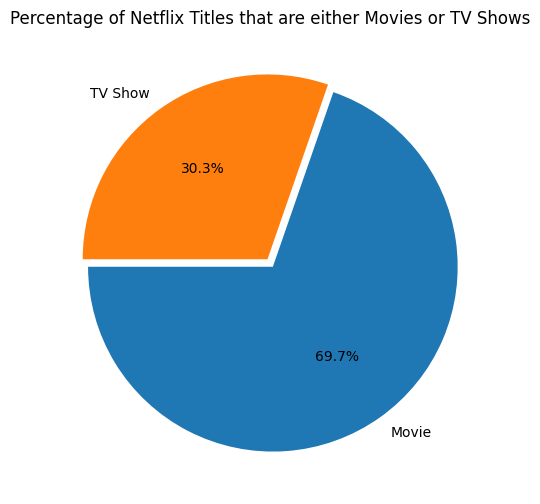

In [ ]:
plt.figure(figsize=(10,6))
plt.title("Percentage of Netflix Titles that are either Movies or TV Shows")
g = plt.pie(df.type.value_counts(),explode=(0.025,0.025), labels=df.type.value_counts().index, autopct="%1.1f%%", startangle=180)
plt.show()

So there are about 6,000+ movies and almost 2,000+ TV shows, with movies being the majority. There are far more movie titles (69.7%) that TV shows titles (30.3%) in terms of title.

5. **Analyze Release Years**

In [ ]:
df['release_year'].value_counts()
# Checking the count of number of releases per year

2018    1146
2017    1030
2019    1030
2020     953
2016     901
        ... 
1959       1
1925       1
1961       1
1947       1
1966       1
Name: release_year, Length: 74, dtype: int64

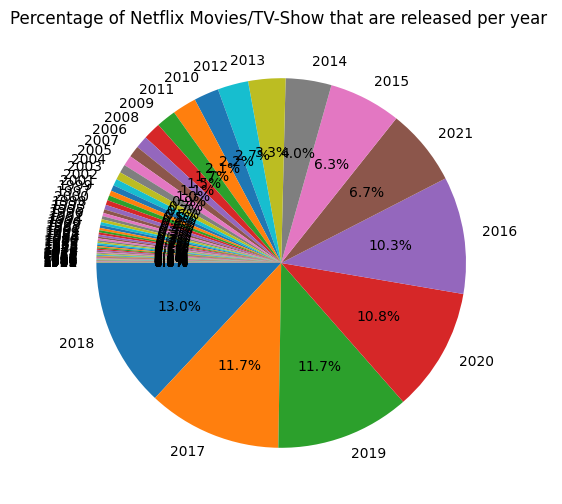

In [ ]:
plt.figure(figsize=(10,6))
plt.title("Percentage of Netflix Movies/TV-Show that are released per year ")
g = plt.pie(df.release_year.value_counts(), labels=df.release_year.value_counts().index, autopct="%1.1f%%", startangle=180)
plt.show()


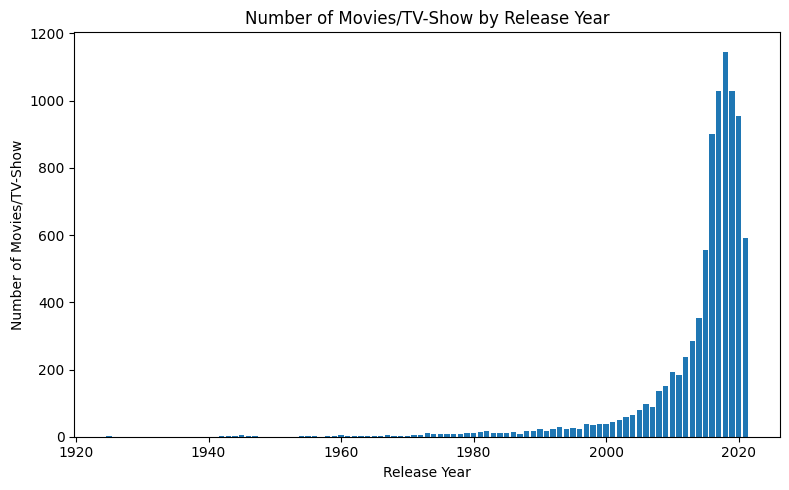

In [ ]:
release_year_counts = df['release_year'].value_counts()
# Checking the count of number of releases per year
plt.figure(figsize=(8, 5))
plt.bar(release_year_counts.index, release_year_counts.values)
plt.xlabel('Release Year')
plt.ylabel('Number of Movies/TV-Show')
plt.title('Number of Movies/TV-Show by Release Year')
plt.xticks(rotation=0)
plt.tight_layout()

plt.show()

We can observe the highest release on Netfix was during the year 2018. And post 2019 it has been on an decreasing trend.

<Figure size 1000x600 with 0 Axes>

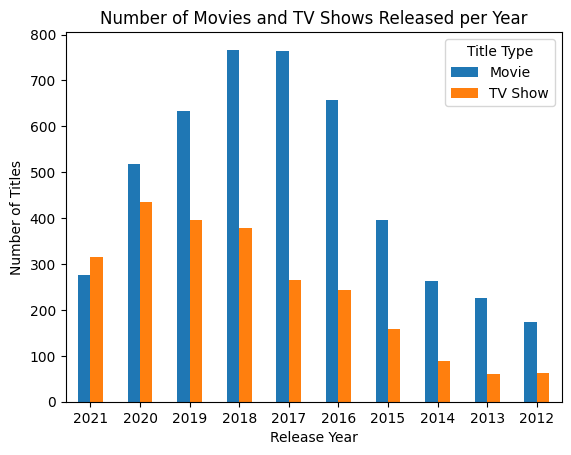

In [ ]:
year_release_counts = df.groupby(['release_year', 'type'])['type'].count().unstack().sort_values(by='release_year',ascending=False).head(10)
# Checking the count of number of releases per year
plt.figure(figsize=(10, 6))
year_release_counts.plot(kind='bar', stacked=False)
plt.xlabel('Release Year')
plt.ylabel('Number of Titles')
plt.title('Number of Movies and TV Shows Released per Year')
plt.legend(title='Title Type')
plt.xticks(rotation=0)

plt.show()

As we can infer from above graph, Movies released was much more than TV-Shows. Although it changed in 2021. In general TV-Show release has been on an increasing trend.

6. **Top Genres**

In [ ]:
unabriged_listed_in=df["listed_in"].apply(lambda x:x.split(", ")).tolist()
# unpacking the listed_in Columns to filter the listed _in columns.

In [ ]:
abridged_listed_in=pd.DataFrame(unabriged_listed_in,index=df["title"]).stack().reset_index().drop(columns="level_1").rename(columns={0:"genre"})
# updating the unpacked data into a new dataframe

In [ ]:
top_10_genres = abridged_listed_in["genre"].value_counts().head(10)
top_10_genres
# Checking the top 10 genres.

International Movies        2752
Dramas                      2426
Comedies                    1674
International TV Shows      1349
Documentaries                869
Action & Adventure           859
TV Dramas                    762
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Name: genre, dtype: int64

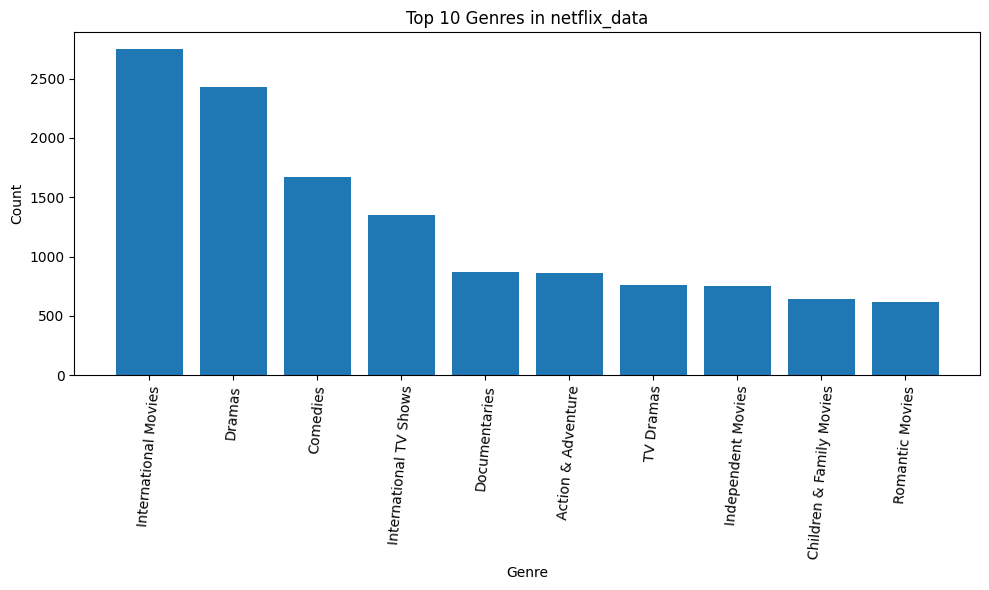

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(top_10_genres.index, top_10_genres.values)
plt.xlabel('Genre')
plt.ylabel('Count')
plt.title('Top 10 Genres in netflix_data')
plt.xticks(rotation=85)
plt.tight_layout()
plt.show()

The top-10 genres were analyzed. International Movies was the number one genre followed by Dramas, Comedies, International TV SHows and so on.

7. **Ratings**

In [ ]:
rating_counts = df['rating'].value_counts()
rating_counts
# Checking the counts of ratings

TV-MA       3205
TV-14       2157
TV-PG        861
R            799
PG-13        490
TV-Y7        333
TV-Y         306
PG           287
TV-G         220
NR            79
G             41
TV-Y7-FV       6
NC-17          3
UR             3
Name: rating, dtype: int64

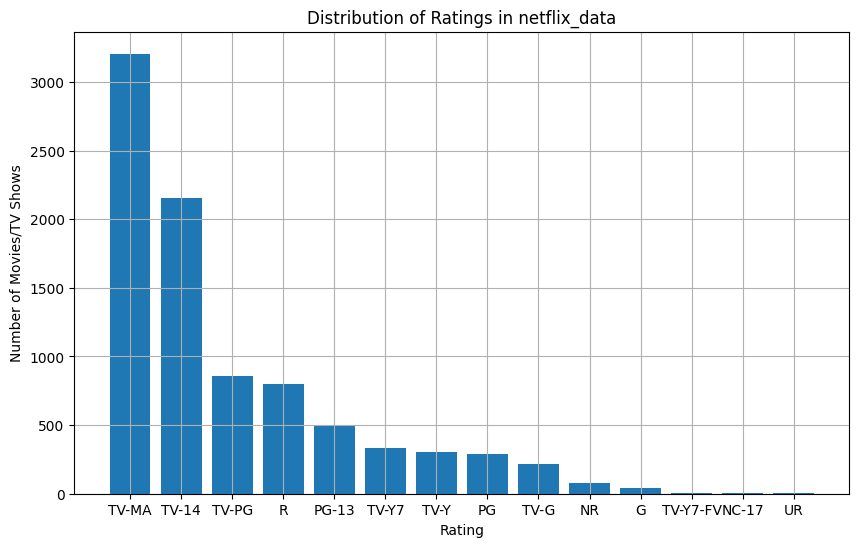

In [ ]:
plt.figure(figsize=(10, 6))
plt.bar(rating_counts.index, rating_counts.values)
plt.xlabel('Rating')
plt.ylabel('Number of Movies/TV Shows')
plt.title('Distribution of Ratings in netflix_data')
plt.grid(True)
plt.show()

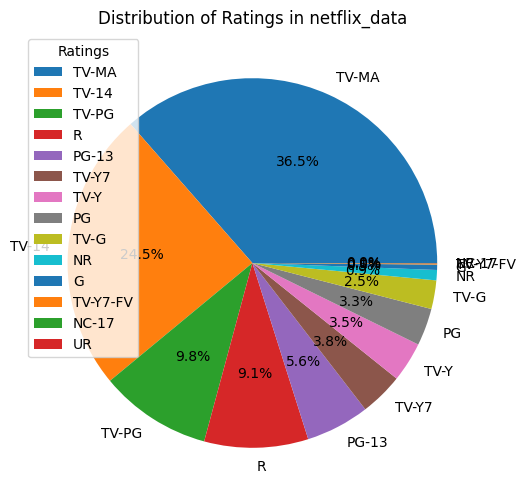

In [ ]:
plt.figure(figsize=(10, 6))
plt.pie(rating_counts.values, labels=rating_counts.index, autopct="%1.1f%%")
plt.title('Distribution of Ratings in netflix_data')
plt.legend(title = "Ratings")
plt.show()

Rating columns was analyzed. It was found that a majority of content was rated TV-MA.

8. **Analysis of duration of Movies and TV Shows**

<ipython-input-25-43a921786b80>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  netflix_movies_df['duration'] = netflix_movies_df['duration'].str.extract('(\d+)',


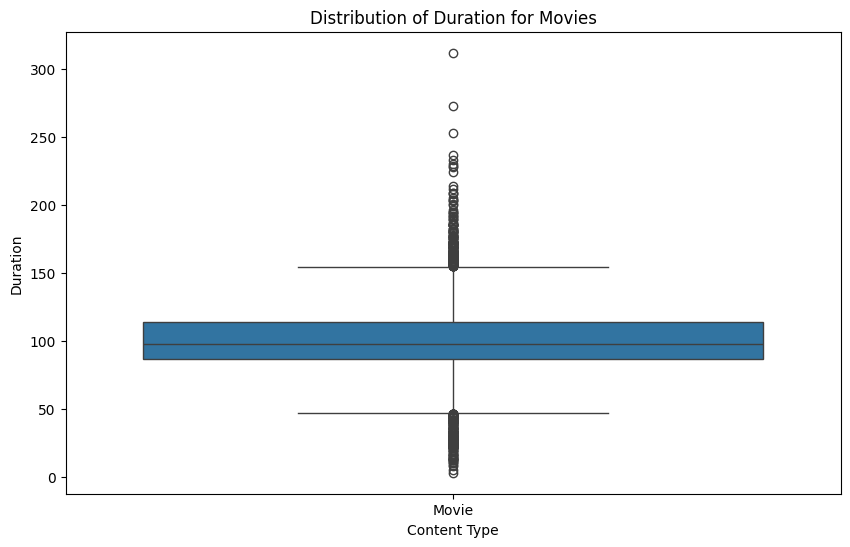

In [ ]:
netflix_movies_df = df[df.type.str.contains("Movie")]
netflix_movies_df['duration'] = netflix_movies_df['duration'].str.extract('(\d+)',
expand=False).astype(int)

# Creating a boxplot for movie duration
plt.figure(figsize=(10, 6))
sns.boxplot(data=netflix_movies_df, x='type', y='duration')
plt.xlabel('Content Type')
plt.ylabel('Duration')
plt.title('Distribution of Duration for Movies')
plt.show()

On analysing the movie box plot, we can see that most movies fall within a reasonable duration range, with few outliers exceedingly approximately 2.5 hours. This suggests that most movies on Netflix are designed to fit within a standard viewing time.

<ipython-input-26-62145178dc08>:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  netflix_shows_df['duration'] = netflix_shows_df['duration'].str.extract('(\d+)',


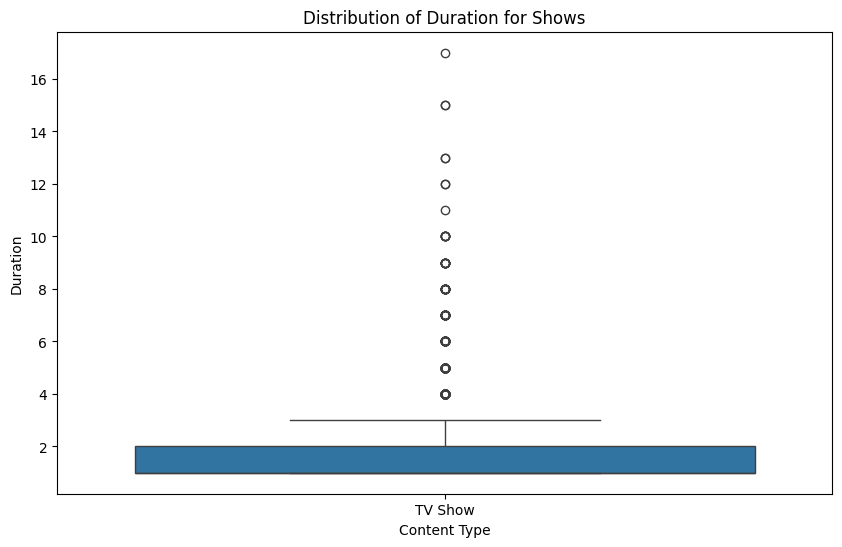

In [ ]:
netflix_shows_df = df[df.type.str.contains("TV Show")]
netflix_shows_df['duration'] = netflix_shows_df['duration'].str.extract('(\d+)',
expand=False).astype(int)

# Creating a boxplot for movie duration
plt.figure(figsize=(10, 6))
sns.boxplot(data=netflix_shows_df, x='type', y='duration')
plt.xlabel('Content Type')
plt.ylabel('Duration')
plt.title('Distribution of Duration for Shows')
plt.show()

On analyzing TV shows, the box plot reveals that most shows have one to four seasons, with very few outliers having longer durations. This aligns with the earlier trends, indicating that Netflix focuses on shorter series formats.

9. **Comparison of tv shows vs. movies.**

Countries by the Amount of the Contents/Movies produced

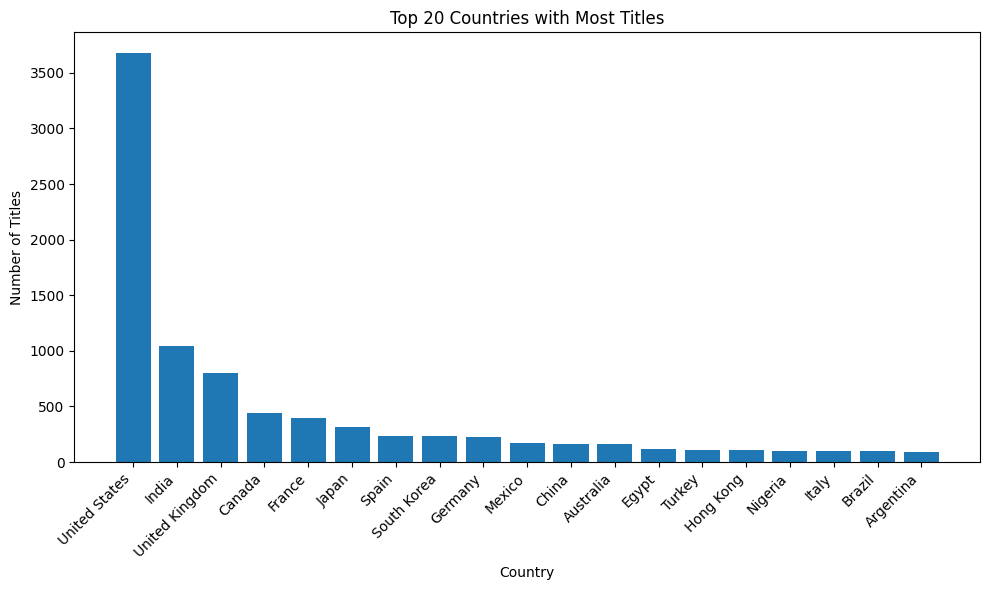

In [ ]:
df['country'] = df['country'].astype(str)
# Converting the country columns to str.
unabriged_country=df["country"].apply(lambda x:x.split(", ")).tolist()
abridged_country=pd.DataFrame(unabriged_country,index=df["title"]).stack().reset_index().drop(columns="level_1").rename(columns={0:"Country"})
x=abridged_country.groupby('Country')["title"].count().to_frame().sort_values(by='title', ascending=False).reset_index().head(20)
x = x[x["Country"]!= "Country Unavailable"]
plt.figure(figsize=(10, 6))
plt.bar(x['Country'], x['title'])
plt.xlabel('Country')
plt.ylabel('Number of Titles')
plt.title('Top 20 Countries with Most Titles')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()


plt.show()

Analysis of Contents produced by countries revealed The United States was found to produce the most number of contents followed by India and so on.

 10. **Find the number of movies produced in each country and pick the top 10
countries.**

In [ ]:
def split_country(df, country_col='country', sep=', '):

  df = df.assign(**{country_col: df[country_col].str.split(sep)})
  return df.explode(country_col)

df1 = split_country(df.copy())
df1 = df1[(df1["country"] != "Country Unavailable") & (df1["type"] == "Movie")]

In [ ]:
df1.groupby(['country'],sort = True)['type'].count().nlargest(10)

country
United States     2748
India              962
United Kingdom     532
Canada             319
France             303
Germany            182
Spain              171
Japan              119
China              114
Mexico             111
Name: type, dtype: int64

The United States produced 2751 movies and is the top one in top 10 countries.

11. **Find the number of TV Show produced in each country and pick the top 10
countries.**

In [ ]:
def split_country(df, country_col='country', sep=', '):

  df = df.assign(**{country_col: df[country_col].str.split(sep)})
  return df.explode(country_col)

df2 = split_country(df.copy())
df2 = df2[(df2["country"] != "Country Unavailable") & (df2["type"] == "TV Show")]

In [ ]:
df2.groupby(['country'],sort = True)['type'].count().nlargest(10)

country
United States     932
United Kingdom    271
Japan             197
South Korea       170
Canada            126
France             90
India              84
Taiwan             70
Australia          64
Spain              61
Name: type, dtype: int64

The United States produced 932 TV Show and is the top one in top 10 countries.

12. **What is the best time to launch a TV show?**




In [ ]:
netflix_shows=df[df['type']=='TV Show']
# checking for only TV Show

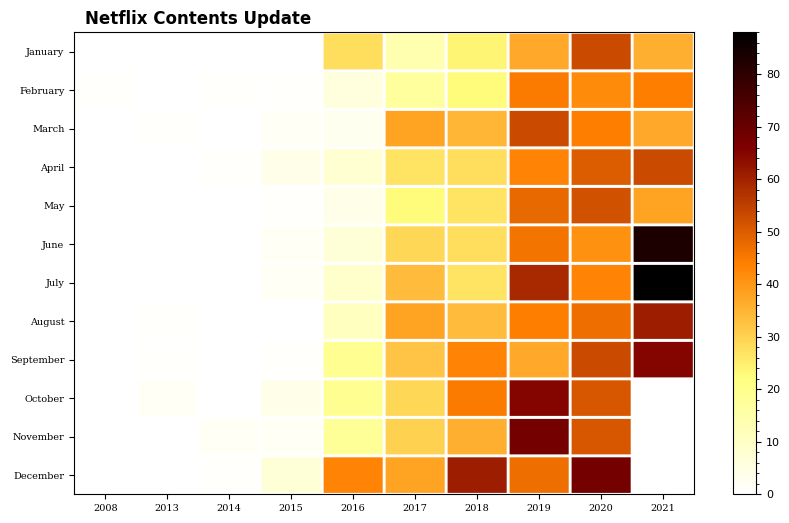

In [ ]:
netflix_date = netflix_shows[['date_added']].dropna()
netflix_date['year'] = netflix_date['date_added'].apply(lambda x : x.split(', ')[-1])
netflix_date['month'] = netflix_date['date_added'].apply(lambda x : x.lstrip().split(' ')[0])

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'][::-1]
df3 = netflix_date.groupby('year')['month'].value_counts().unstack().fillna(0)[month_order].T
plt.figure(figsize=(10, 6))
plt.pcolor(df3, cmap='afmhot_r', edgecolors='white', linewidths=2) # heatmap
plt.xticks(np.arange(0.5, len(df3.columns), 1), df3.columns, fontsize=7, fontfamily='serif')
plt.yticks(np.arange(0.5, len(df3.index), 1), df3.index, fontsize=7, fontfamily='serif')

plt.title('Netflix Contents Update', fontsize=12, fontweight='bold', position=(0.20, 1.0+0.02))
cbar = plt.colorbar()

cbar.ax.tick_params(labelsize=8)
cbar.ax.minorticks_on()
plt.show()

In July 2021 highest number of films were added.

13. **What is the best time to launch a Movie?**

In [ ]:
netflix_movies = df[df["type"]=="Movie"]
# Checking for Movie

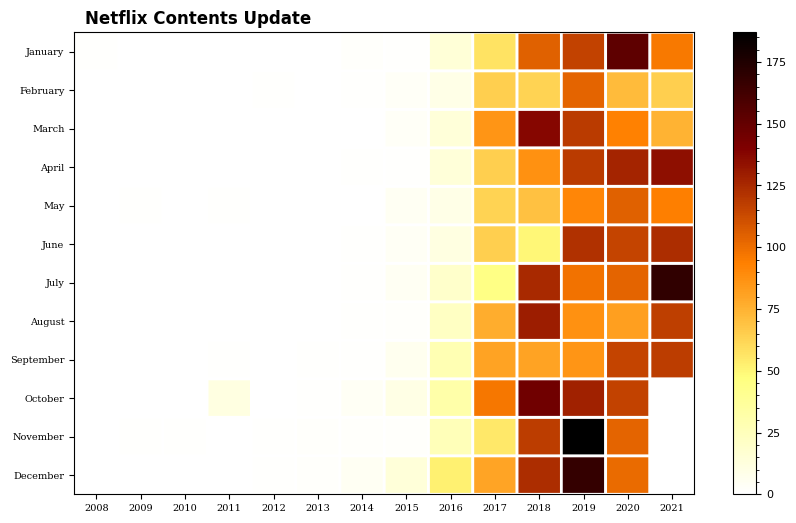

In [ ]:
netflix_date = netflix_movies[['date_added']].dropna()
netflix_date['year'] = netflix_date['date_added'].apply(lambda x : x.split(', ')[-1])
netflix_date['month'] = netflix_date['date_added'].apply(lambda x : x.lstrip().split(' ')[0])

month_order = ['January', 'February', 'March', 'April', 'May', 'June', 'July', 'August', 'September', 'October', 'November', 'December'][::-1]
df4 = netflix_date.groupby('year')['month'].value_counts().unstack().fillna(0)[month_order].T
plt.figure(figsize=(10, 6))
plt.pcolor(df4, cmap='afmhot_r', edgecolors='white', linewidths=2) # heatmap
plt.xticks(np.arange(0.5, len(df4.columns), 1), df4.columns, fontsize=7, fontfamily='serif')
plt.yticks(np.arange(0.5, len(df4.index), 1), df4.index, fontsize=7, fontfamily='serif')

plt.title('Netflix Contents Update', fontsize=12, fontweight='bold', position=(0.20, 1.0+0.02))
cbar = plt.colorbar()

cbar.ax.tick_params(labelsize=8)
cbar.ax.minorticks_on()
plt.show()

In July 2021 most Movies were added.

14. **Which genre movies are more popular or produced more?**

In [ ]:
from wordcloud import WordCloud, ImageColorGenerator
text = " ".join(str(each) for each in df.listed_in)

<Figure size 1000x600 with 0 Axes>

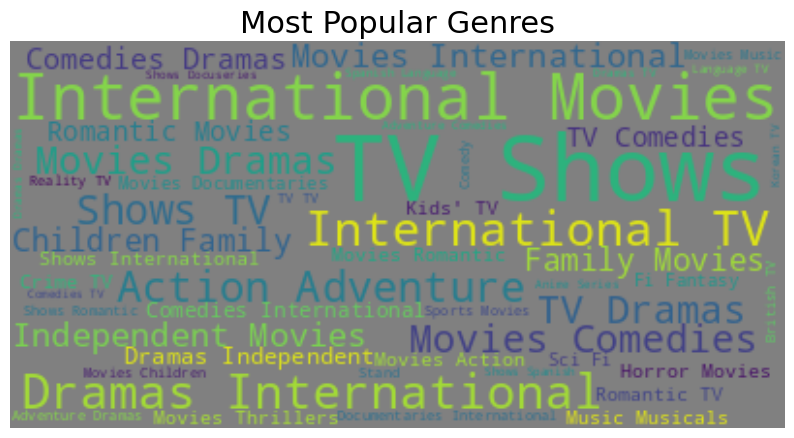

In [ ]:
# Create and generate a word cloud image:
wordcloud = WordCloud(max_words=200, background_color="gray").generate(text)
plt.figure(figsize=(10, 6))
plt.figure(figsize=(10, 6))
# Display the generated image:
plt.imshow(wordcloud, interpolation='Bilinear')
plt.title('Most Popular Genres',fontsize = 22)
plt.axis("off")
plt.show()

15. **Which themes are more popular or produced more?**

<Figure size 1000x600 with 0 Axes>

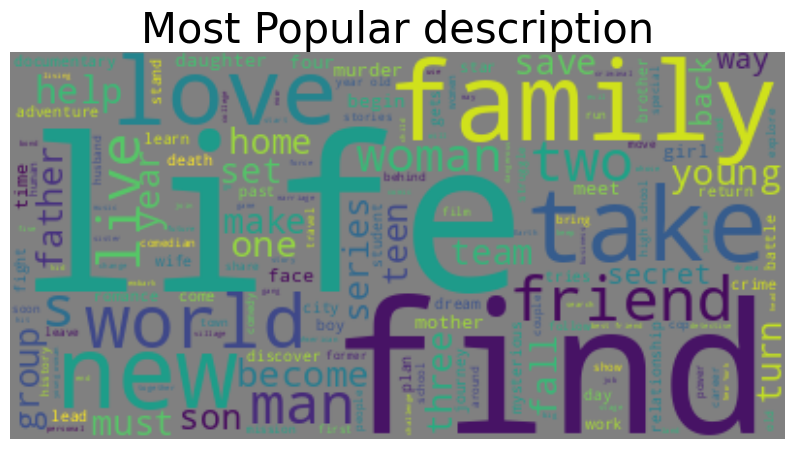

In [ ]:
from wordcloud import WordCloud, ImageColorGenerator
text = " ".join(str(each) for each in df.description)
# Create and generate a word cloud image:
wordcloud = WordCloud(max_words=200, background_color="gray").generate(text)
plt.figure(figsize=(10, 6))
plt.figure(figsize=(10, 6))
# Display the generated image:
plt.imshow(wordcloud, interpolation='Bilinear')
plt.title('Most Popular description',fontsize = 30)
plt.axis("off")
plt.show()

16. **Top Actor on Netflix based on the number of titles**

In [ ]:
netflix_shows_df=df[df['type']=='TV Show']
filtered_cast_shows = netflix_shows_df[netflix_shows_df.cast != "No Cast"].set_index("title").cast.str.split(", ", expand=True).stack().reset_index(level=1, drop=True)

In [ ]:
top_actors_show =filtered_cast_shows.value_counts().reset_index().head(10)
top_actors_show

,index,0
0,Takahiro Sakurai,25
1,Yuki Kaji,19
2,Daisuke Ono,17
3,Junichi Suwabe,17
4,Ai Kayano,16
5,Yuichi Nakamura,16
6,Yoshimasa Hosoya,15
7,Jun Fukuyama,15
8,David Attenborough,14
9,Takehito Koyasu,13


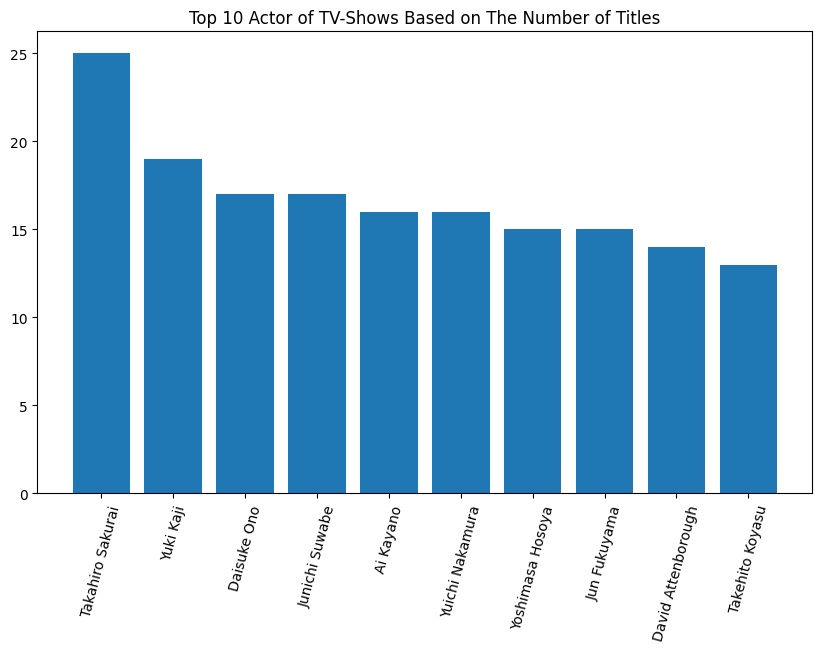

In [ ]:
plt.figure(figsize=(10, 6))
plt.title("Top 10 Actor of TV-Shows Based on The Number of Titles")
plt.bar(top_actors_show["index"],top_actors_show[0])
plt.xticks(rotation=75)
plt.show()

The top actor on Netflix TV Show, based on the number of titles, is Takahiro Sakurai.

In [ ]:
netflix_movies_df=df[df['type']=='Movie']
filtered_cast_movies = netflix_movies_df[netflix_movies_df.cast != "No Cast"].set_index("title").cast.str.split(", ", expand=True).stack().reset_index(level=1, drop=True)

In [ ]:
top_actors_movies =filtered_cast_movies.value_counts().reset_index().head(10)
top_actors_movies

,index,0
0,Anupam Kher,42
1,Shah Rukh Khan,35
2,Naseeruddin Shah,32
3,Om Puri,30
4,Akshay Kumar,30
5,Julie Tejwani,28
6,Paresh Rawal,28
7,Amitabh Bachchan,28
8,Rupa Bhimani,27
9,Boman Irani,27


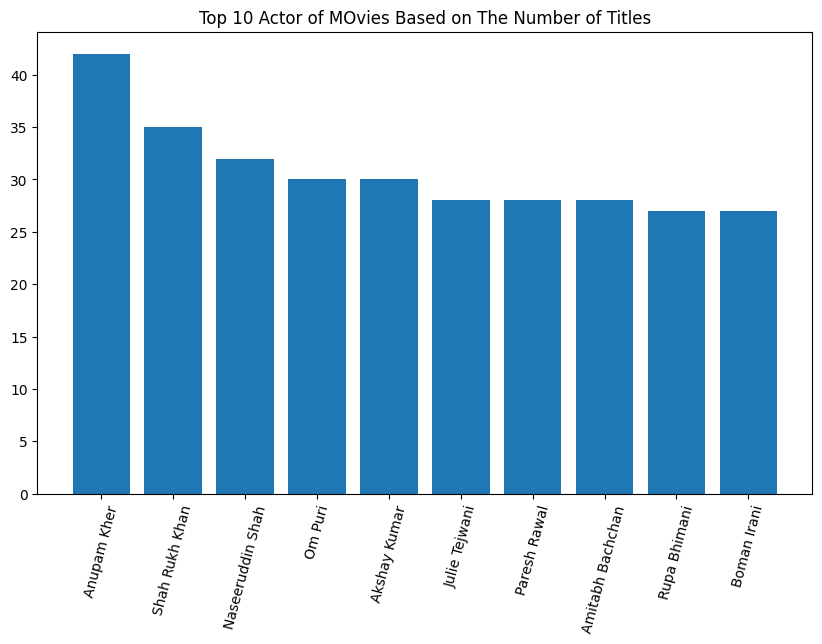

In [ ]:
plt.figure(figsize=(10, 6))
plt.title("Top 10 Actor of MOvies Based on The Number of Titles")
plt.bar(top_actors_movies["index"],top_actors_movies[0])
plt.xticks(rotation=75)
plt.show()

The top actor on Netflix Movies, based on the number of titles, is Anupam Kher.

17. **Top Director on Netflix based on the number of titles**

In [ ]:
netflix_shows_df=df[df['type']=='TV Show']
filtered_director_shows = netflix_shows_df[netflix_shows_df.director != "No Director"].set_index("title").director.str.split(", ", expand=True).stack().reset_index(level=1, drop=True)

In [ ]:
top_director_show =filtered_director_shows.value_counts().reset_index().head(10)
top_director_show

,index,0
0,Alastair Fothergill,3
1,Ken Burns,3
2,Jung-ah Im,2
3,Gautham Vasudev Menon,2
4,Iginio Straffi,2
5,Hsu Fu-chun,2
6,Stan Lathan,2
7,Joe Berlinger,2
8,Shin Won-ho,2
9,Lynn Novick,2


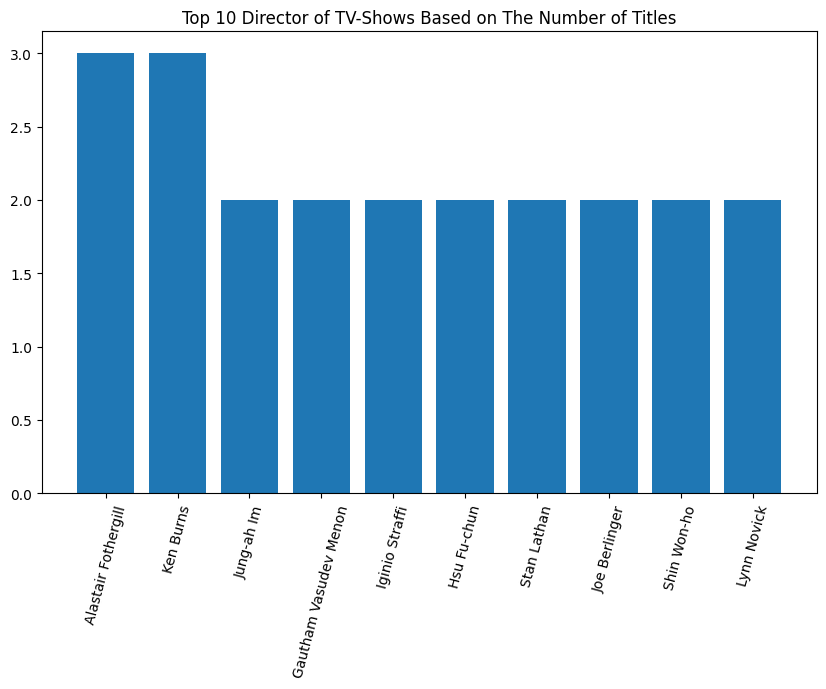

In [ ]:
plt.figure(figsize=(10,6))
plt.title("Top 10 Director of TV-Shows Based on The Number of Titles")
plt.bar(top_director_show["index"],top_director_show[0])
plt.xticks(rotation=75)
plt.show()

The most popular director on Netflix TV-Show, with the most titles, is Alastair Fothergill and	Ken Burns.








In [ ]:
netflix_movies_df=df[df['type']=='Movie']
filtered_director_movies = netflix_movies_df[netflix_movies_df.director != "No Director"].set_index("title").director.str.split(", ", expand=True).stack().reset_index(level=1, drop=True)

In [ ]:
top_director_movies =filtered_director_movies.value_counts().reset_index().head(10)
top_director_movies

,index,0
0,Rajiv Chilaka,22
1,Jan Suter,21
2,Raúl Campos,19
3,Suhas Kadav,16
4,Jay Karas,15
5,Marcus Raboy,15
6,Cathy Garcia-Molina,13
7,Youssef Chahine,12
8,Jay Chapman,12
9,Martin Scorsese,12


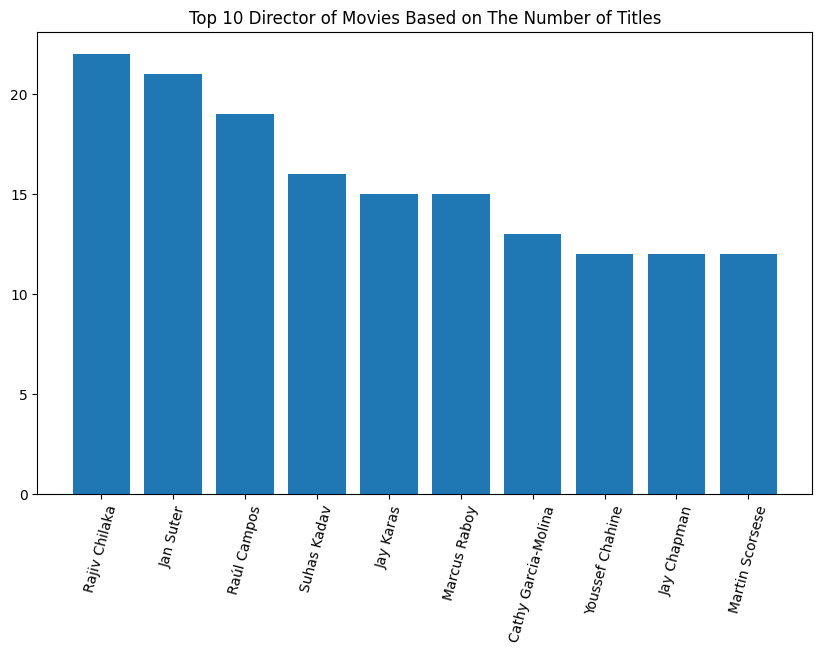

In [ ]:
plt.figure(figsize=(10,6))
plt.title("Top 10 Director of Movies Based on The Number of Titles")
plt.bar(top_director_movies["index"],top_director_movies[0])
plt.xticks(rotation=75)
plt.show()

The most popular director on Netflix Movies, with the most titles, is Rajiv Chilaka.


**What we learned about Netflix:**

Movies rule: There are simply more movies than TV shows on Netflix.

Strategic stocking: July and December are prime times for new content to hit the platform.

Genre mashup magic: Viewers seem to enjoy certain genre combinations, like international dramas, romantic international shows, and indie movies with dramatic flair.

Movie marathons or quick binges?: Movie lengths peaked in the 1960s, but now most settle around the 2-hour mark. On the other hand, most TV shows only have one season, suggesting viewers prefer shorter series.

Love is in the air (and the descriptions): Words like love, life, family, and adventure pop up frequently, hinting at common themes explored in Netflix content.

Ratings reveal the story: The largest count of Netflix content is made with a “TV-MA” rating.

Top Actor: The most popular actor on Netflix TV Shows based on the number of titles is Takahiro Sakurai and The top actor on Netflix Movies, based on the number of titles, is Anupam Kher.

Top Director: The most popular director on Netflix TV-Show , with the most titles, is Alastair Fothergill and Ken Burns. The most popular director on Netflix Movies, with the most titles, is Rajiv Chilaka.

Data is king: By digging into the data, we can unlock the secrets of Netflix's content strategy, which is helpful for both viewers looking for the perfect show and creators who want to know what works. The popular streaming platform started gaining traction after 2014. Since then, the amount of content added has been increasing significantly.

Staying ahead of the curve: As the streaming world keeps changing, understanding these trends is more important than ever.

The takeaway? Happy streaming!

This analysis gives us a glimpse into what makes Netflix tick, why viewers keep coming back, and what kind of content gets the green light.  Let data be your guide as you explore the ever-expanding world of Netflix!




**Recommendations**

Netflix has to focus on TV Shows also because there are people who will like to see  tv shows rather than movies  

We have seen most no of international movies genre so need to give priority to other genres.  

Most of the movies released in ott is in the year 2019 so we need work on increasing  this value in order to attract people by showing that getting subscription is usefull as netflix is releasing more movies per year.  

